# 01 -- EDA and Stationarity

**Sentinel-alpha** -- Module #4 PoliMI Business Case #4

This notebook documents the input data, the per-type stationarity transforms applied, and the engineered features. All analysis here is purely descriptive; modeling starts in 02.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sentinel_alpha.data.loader import load_dataset
from sentinel_alpha.data.transforms import stationarize
from sentinel_alpha.features.engineer import add_engineered
sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize']=(11,4)

## Raw dataset

Bloomberg weekly snapshots, 2000-01-11 -> 2021-04-20.

In [2]:
d = load_dataset()
print('X shape', d.X.shape, '| Y shape', d.y.shape)
print('Y rate', d.y.mean().round(4), '| weekly cadence verified')
from collections import Counter
print('Asset-type histogram:', Counter(d.type_map.values()))
d.X.head(3)

X shape (1111, 42) | Y shape (1111,)
Y rate 0.2133 | weekly cadence verified
Asset-type histogram: Counter({'Bond Yield': 16, 'Bond Index': 8, 'Equity Index': 7, 'Currency': 3, 'Commodity': 2, 'Economic Index': 2, 'Interest rate': 2, 'Commodity Index': 1, 'Volatility Index': 1})


,BDIY,CRY,Cl1,DXY,ECSURPUS,EMUSTRUU,EONIA,GBP,GT10,GTDEM10Y,...,MXIN,MXJP,MXRU,MXUS,US0001M,USGG2YR,USGG30YR,USGG3M,VIX,XAUBGNL
date,,,,,,,,,,,,,,,,,,,,,
2000-01-11,1388.0,157.26,25.77,100.56,0.077,230.5267,2.89,1.6460,6.657,5.541,...,217.34,990.59,224.33,1416.12,5.78125,6.428,6.671,5.426,22.50,283.25
2000-01-18,1405.0,165.01,28.85,101.86,0.043,231.3770,3.03,1.6383,6.748,5.644,...,227.08,993.98,234.37,1428.79,5.80250,6.465,6.747,5.378,21.50,287.65
2000-01-25,1368.0,167.24,28.28,102.41,0.135,232.3895,3.15,1.6496,6.692,5.515,...,233.00,974.83,216.82,1385.93,5.81875,6.432,6.634,5.562,23.02,287.15


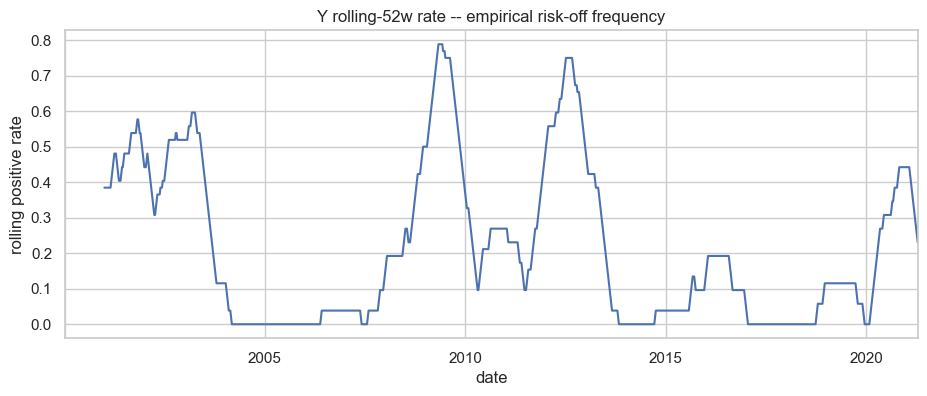

In [3]:
ax = d.y.rolling(52).mean().plot(title='Y rolling-52w rate -- empirical risk-off frequency')
ax.set_ylabel('rolling positive rate'); plt.show()

## Stationarity, by metadata type

Rates can go negative (Bunds, JGB), so we use first differences in bps. Bond/equity/FX/commodity total-return-style series get log-returns. VIX is kept as both level and difference.

In [4]:
Z = stationarize(d.X, d.type_map)
print('Stationarized shape', Z.shape)
print('VIX columns:', [c for c in Z.columns if c.startswith('VIX')])
Z.describe().T[['mean','std','min','max']].head(8)

Stationarized shape (1110, 43)
VIX columns: ['VIX_lvl', 'VIX_d']


,mean,std,min,max
BDIY_logret,0.000505,0.086928,-0.479494,0.542041
CRY_logret,0.000188,0.024959,-0.170182,0.133358
Cl1_logret,0.000798,0.060811,-0.697633,0.688273
DXY_logret,-0.000089,0.010977,-0.061922,0.038230
ECSURPUS_lvl,0.036116,0.349609,-0.974000,0.991000
EMUSTRUU_logret,0.001531,0.010655,-0.102506,0.101195
EONIA_dbps,-0.303604,15.634002,-111.000000,98.000000
GBP_logret,-0.000149,0.013126,-0.095317,0.055982


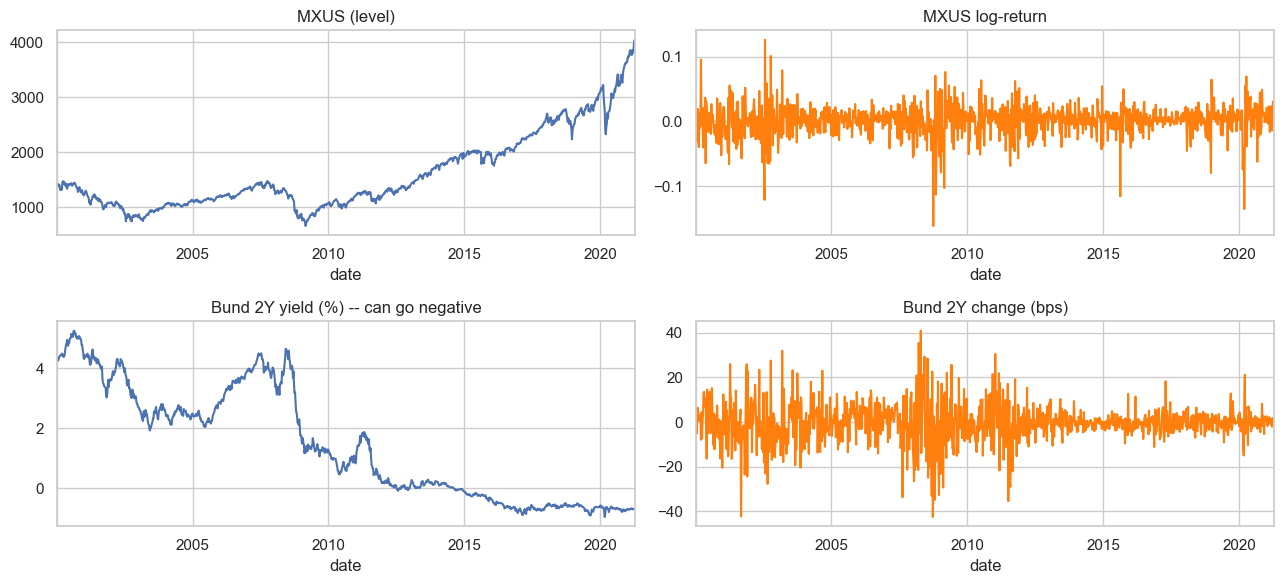

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
d.X['MXUS'].plot(ax=axes[0,0], title='MXUS (level)')
Z['MXUS_logret'].plot(ax=axes[0,1], title='MXUS log-return', color='tab:orange')
d.X['GTDEM2Y'].plot(ax=axes[1,0], title='Bund 2Y yield (%) -- can go negative')
Z['GTDEM2Y_dbps'].plot(ax=axes[1,1], title='Bund 2Y change (bps)', color='tab:orange')
plt.tight_layout(); plt.show()

## Engineered features

On top of the raw stationarized matrix we add cross-asset stress signals (realized vol, equity-credit correlation, term spread, credit excess, VIX z-score) and a risk-appetite composite used downstream by the gate.

In [6]:
F, ra = add_engineered(Z)
eng = [c for c in F.columns if c.startswith('ENG_')]
print('# engineered features:', len(eng))
print(eng)
F.shape

# engineered features: 7
['ENG_eq_dm', 'ENG_eq_vol4w', 'ENG_eq_credit_corr4w', 'ENG_term_spread_d', 'ENG_credit_excess', 'ENG_vix_z52', 'ENG_vix_d']


(1109, 93)

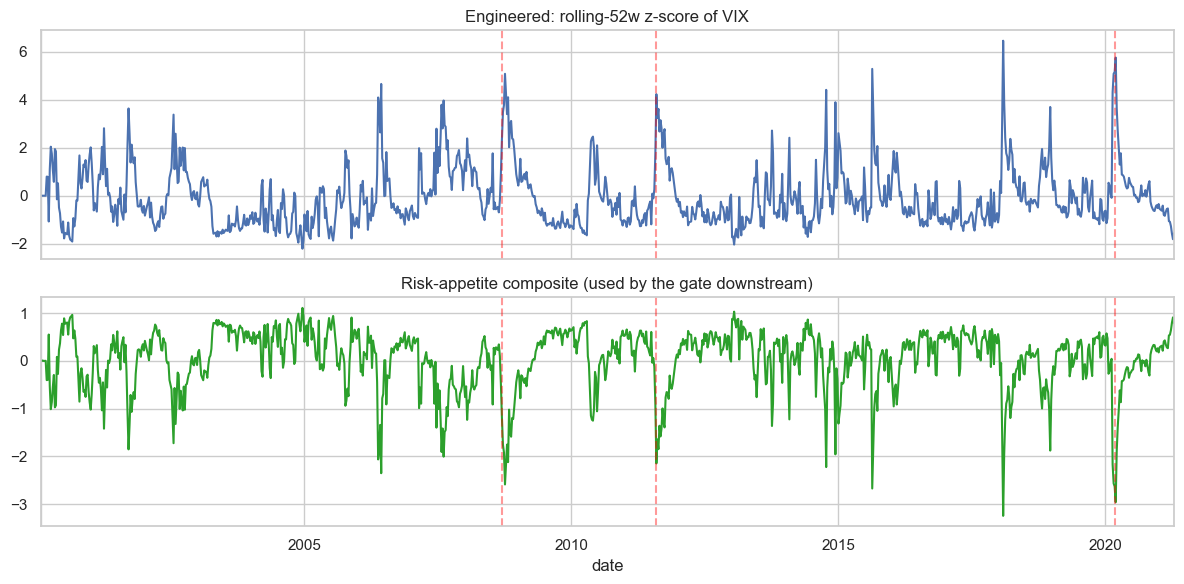

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
F['ENG_vix_z52'].plot(ax=axes[0], title='Engineered: rolling-52w z-score of VIX')
ra.plot(ax=axes[1], title='Risk-appetite composite (used by the gate downstream)', color='tab:green')
for d_, _ in [('2008-09-15','GFC'), ('2020-03-09','COVID'), ('2011-08-08','EU sov')]:
    for a in axes:
        a.axvline(pd.Timestamp(d_), color='red', alpha=0.4, ls='--')
plt.tight_layout(); plt.show()

## Y label by year

Useful sanity check: confirms positive labels cover all five named crises.

In [8]:
tab = d.y.to_frame().assign(yr=d.y.index.year).groupby('yr').agg(n=('Y','size'), pos=('Y','sum'))
tab['rate']=tab['pos']/tab['n']; tab

,n,pos,rate
yr,,,
2000,51,19,0.372549
2001,52,24,0.461538
2002,53,27,0.509434
2003,52,6,0.115385
2004,52,0,0.000000
2005,52,0,0.000000
2006,52,2,0.038462
2007,52,6,0.115385
2008,53,27,0.509434
